# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "all-sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
20,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
149,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
278,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
407,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
536,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39848126,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302957e+06,783.724370,0.368939,0.215918,4.263644,0.0,20.0,20.0000,-8.7776,0.027191,1.122812,0.000533,6.028162e+06,3.349485,2.651569,0.000090,0.000392
39848255,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302920e+06,963.710828,0.445028,0.264413,4.272375,0.0,20.0,20.0000,-5.1360,0.027191,1.122806,0.000659,6.028195e+06,3.349485,2.651569,0.000108,0.000482
39848384,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302317e+06,3528.295515,1.086090,0.698499,4.217698,0.0,20.0,20.0000,-9.4800,0.027186,1.122714,0.002410,6.028750e+06,3.349485,2.651569,0.000410,0.001764
39848513,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.287471e+06,58227.795937,3.552002,1.233668,2.426244,0.0,20.0,5.1264,-11.3440,0.027066,1.120395,0.195402,6.042383e+06,3.349485,2.651569,0.007833,0.029114


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Threshold"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

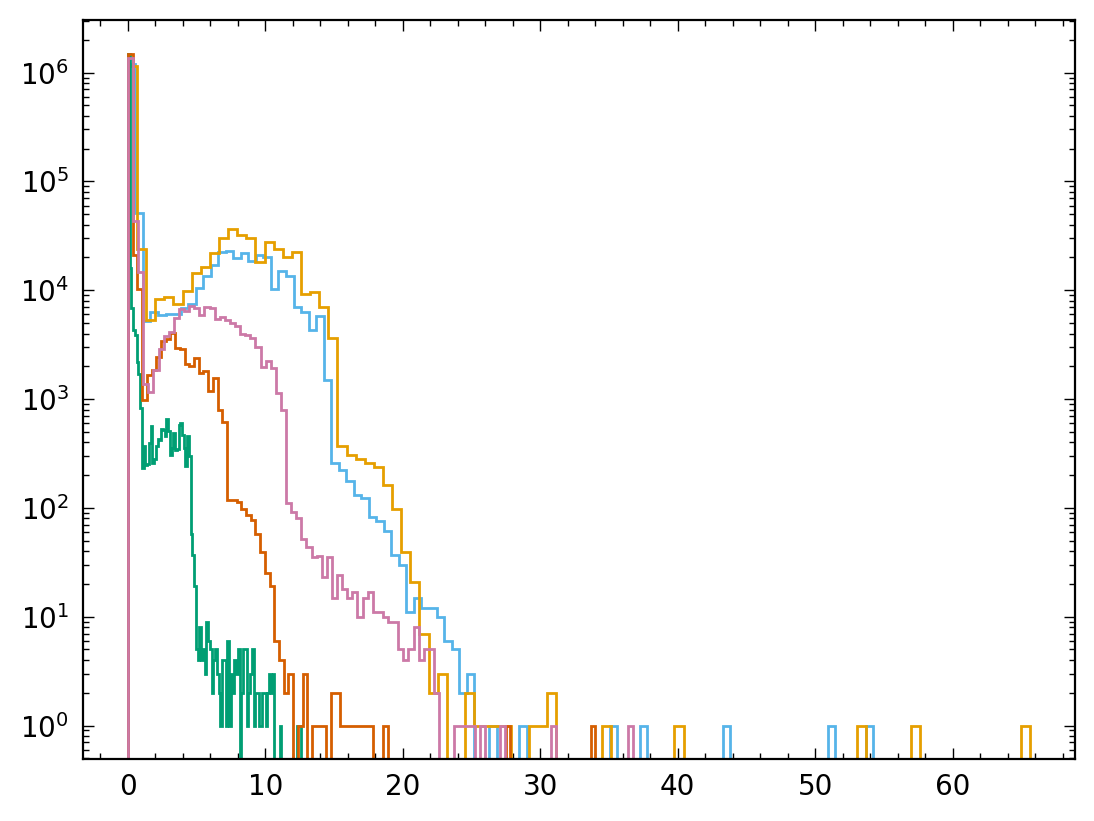

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-26.795884,1.680385,1.061431,0.660586
1,-6.698971,3.212106,1.055471,0.767532
2,0.700124,0.210889,1.162062,0.128139
3,0.717337,0.280463,1.342023,0.179417
4,0.735609,0.341204,1.457535,0.238702
...,...,...,...,...
100,2.677607,4.729276,1.638634,0.514408
101,2.813581,5.058422,1.663586,0.557280
102,3.349485,0.026993,1.117699,0.106458
103,5.359177,0.143080,1.114682,0.152325


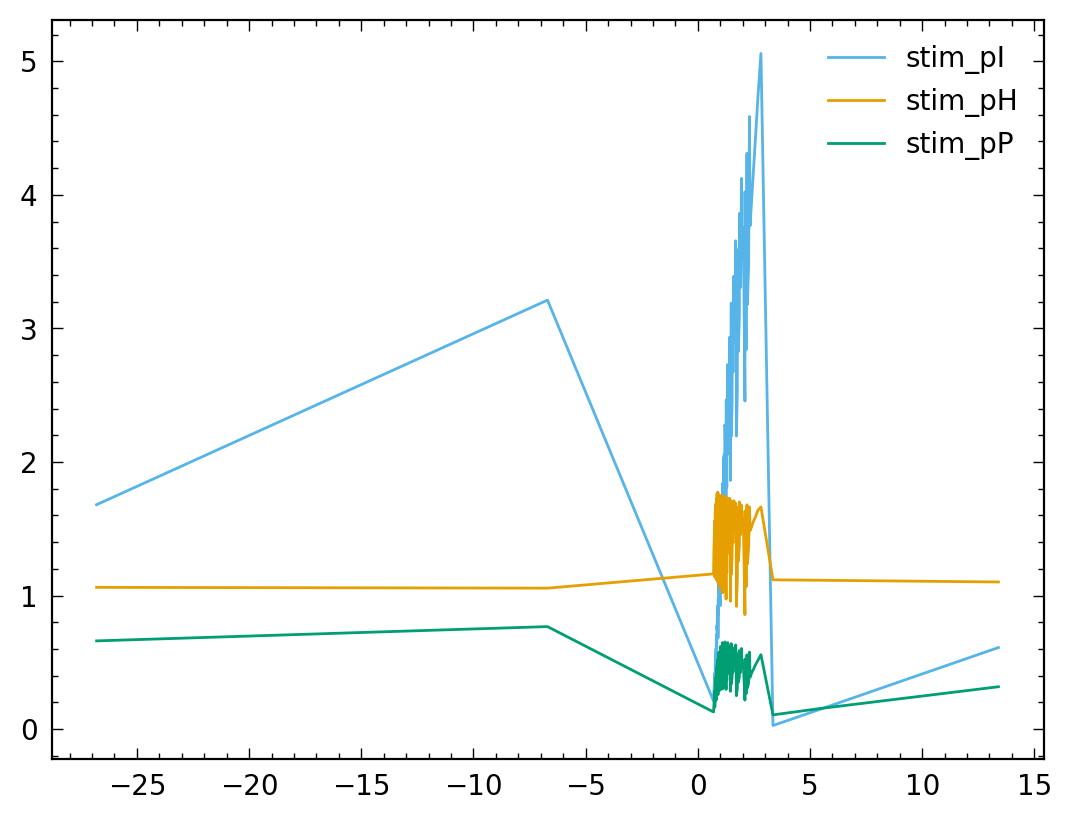

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 8
fevals: 12
fevals: 14
fevals: 70


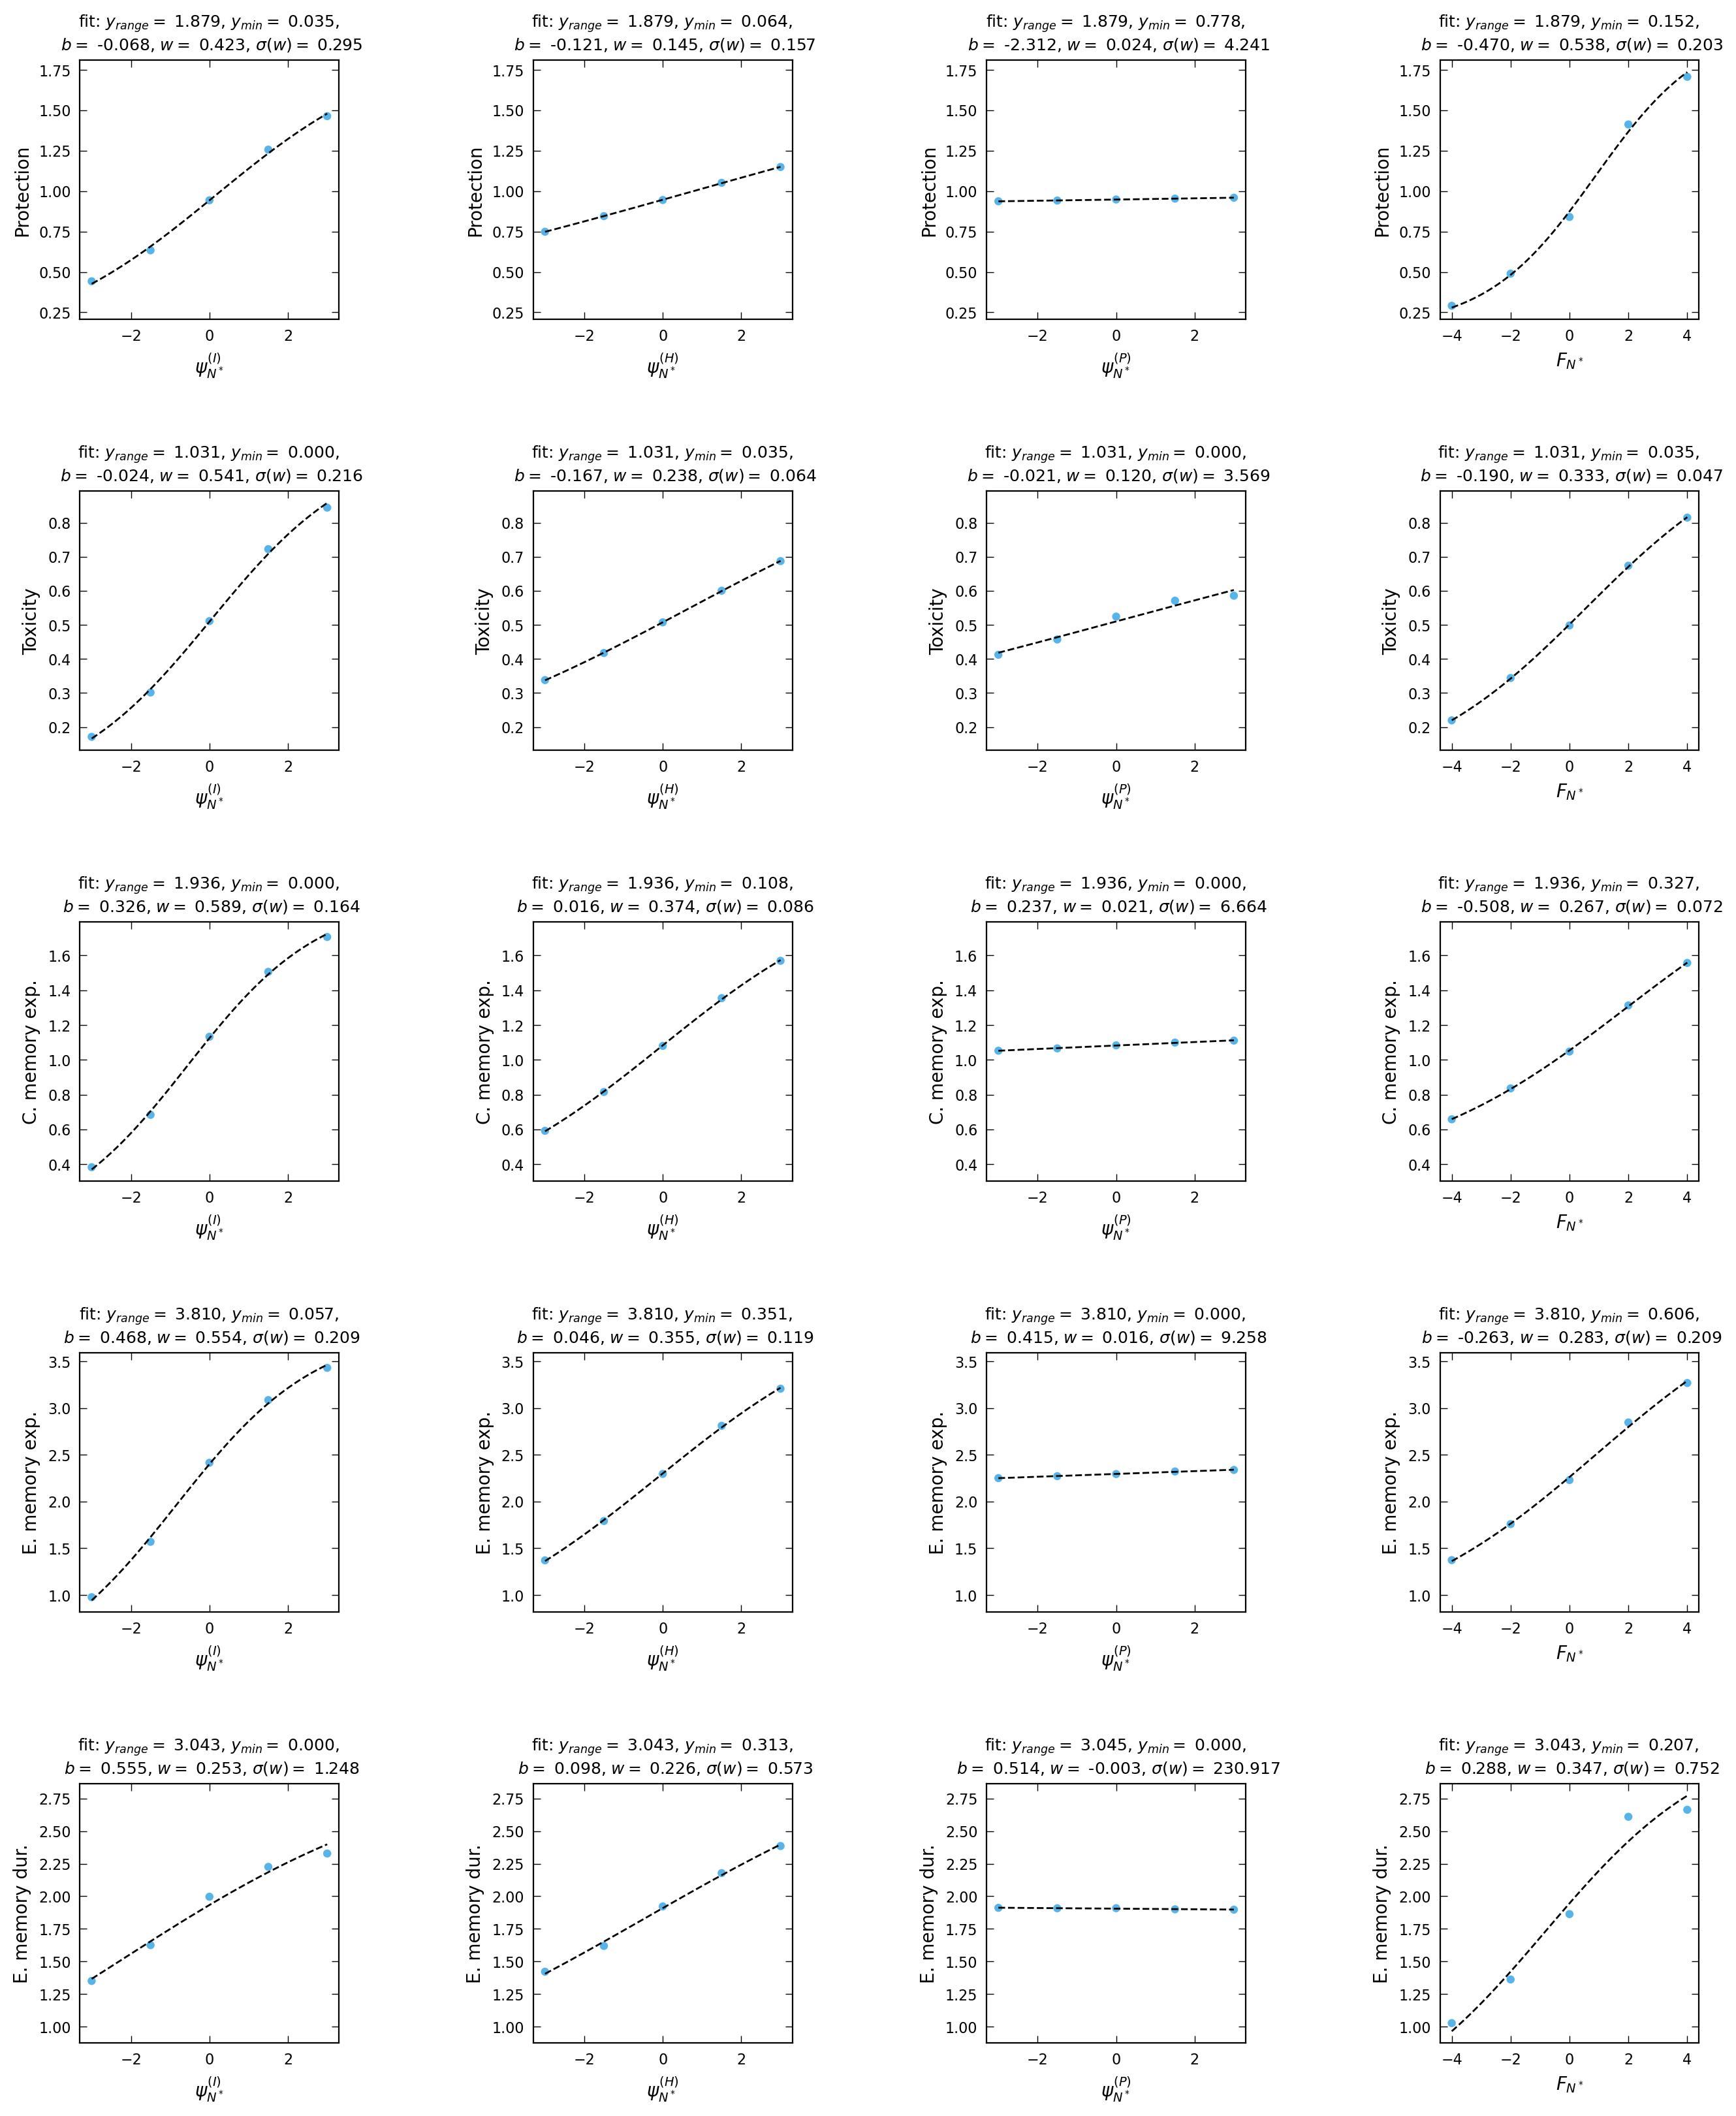

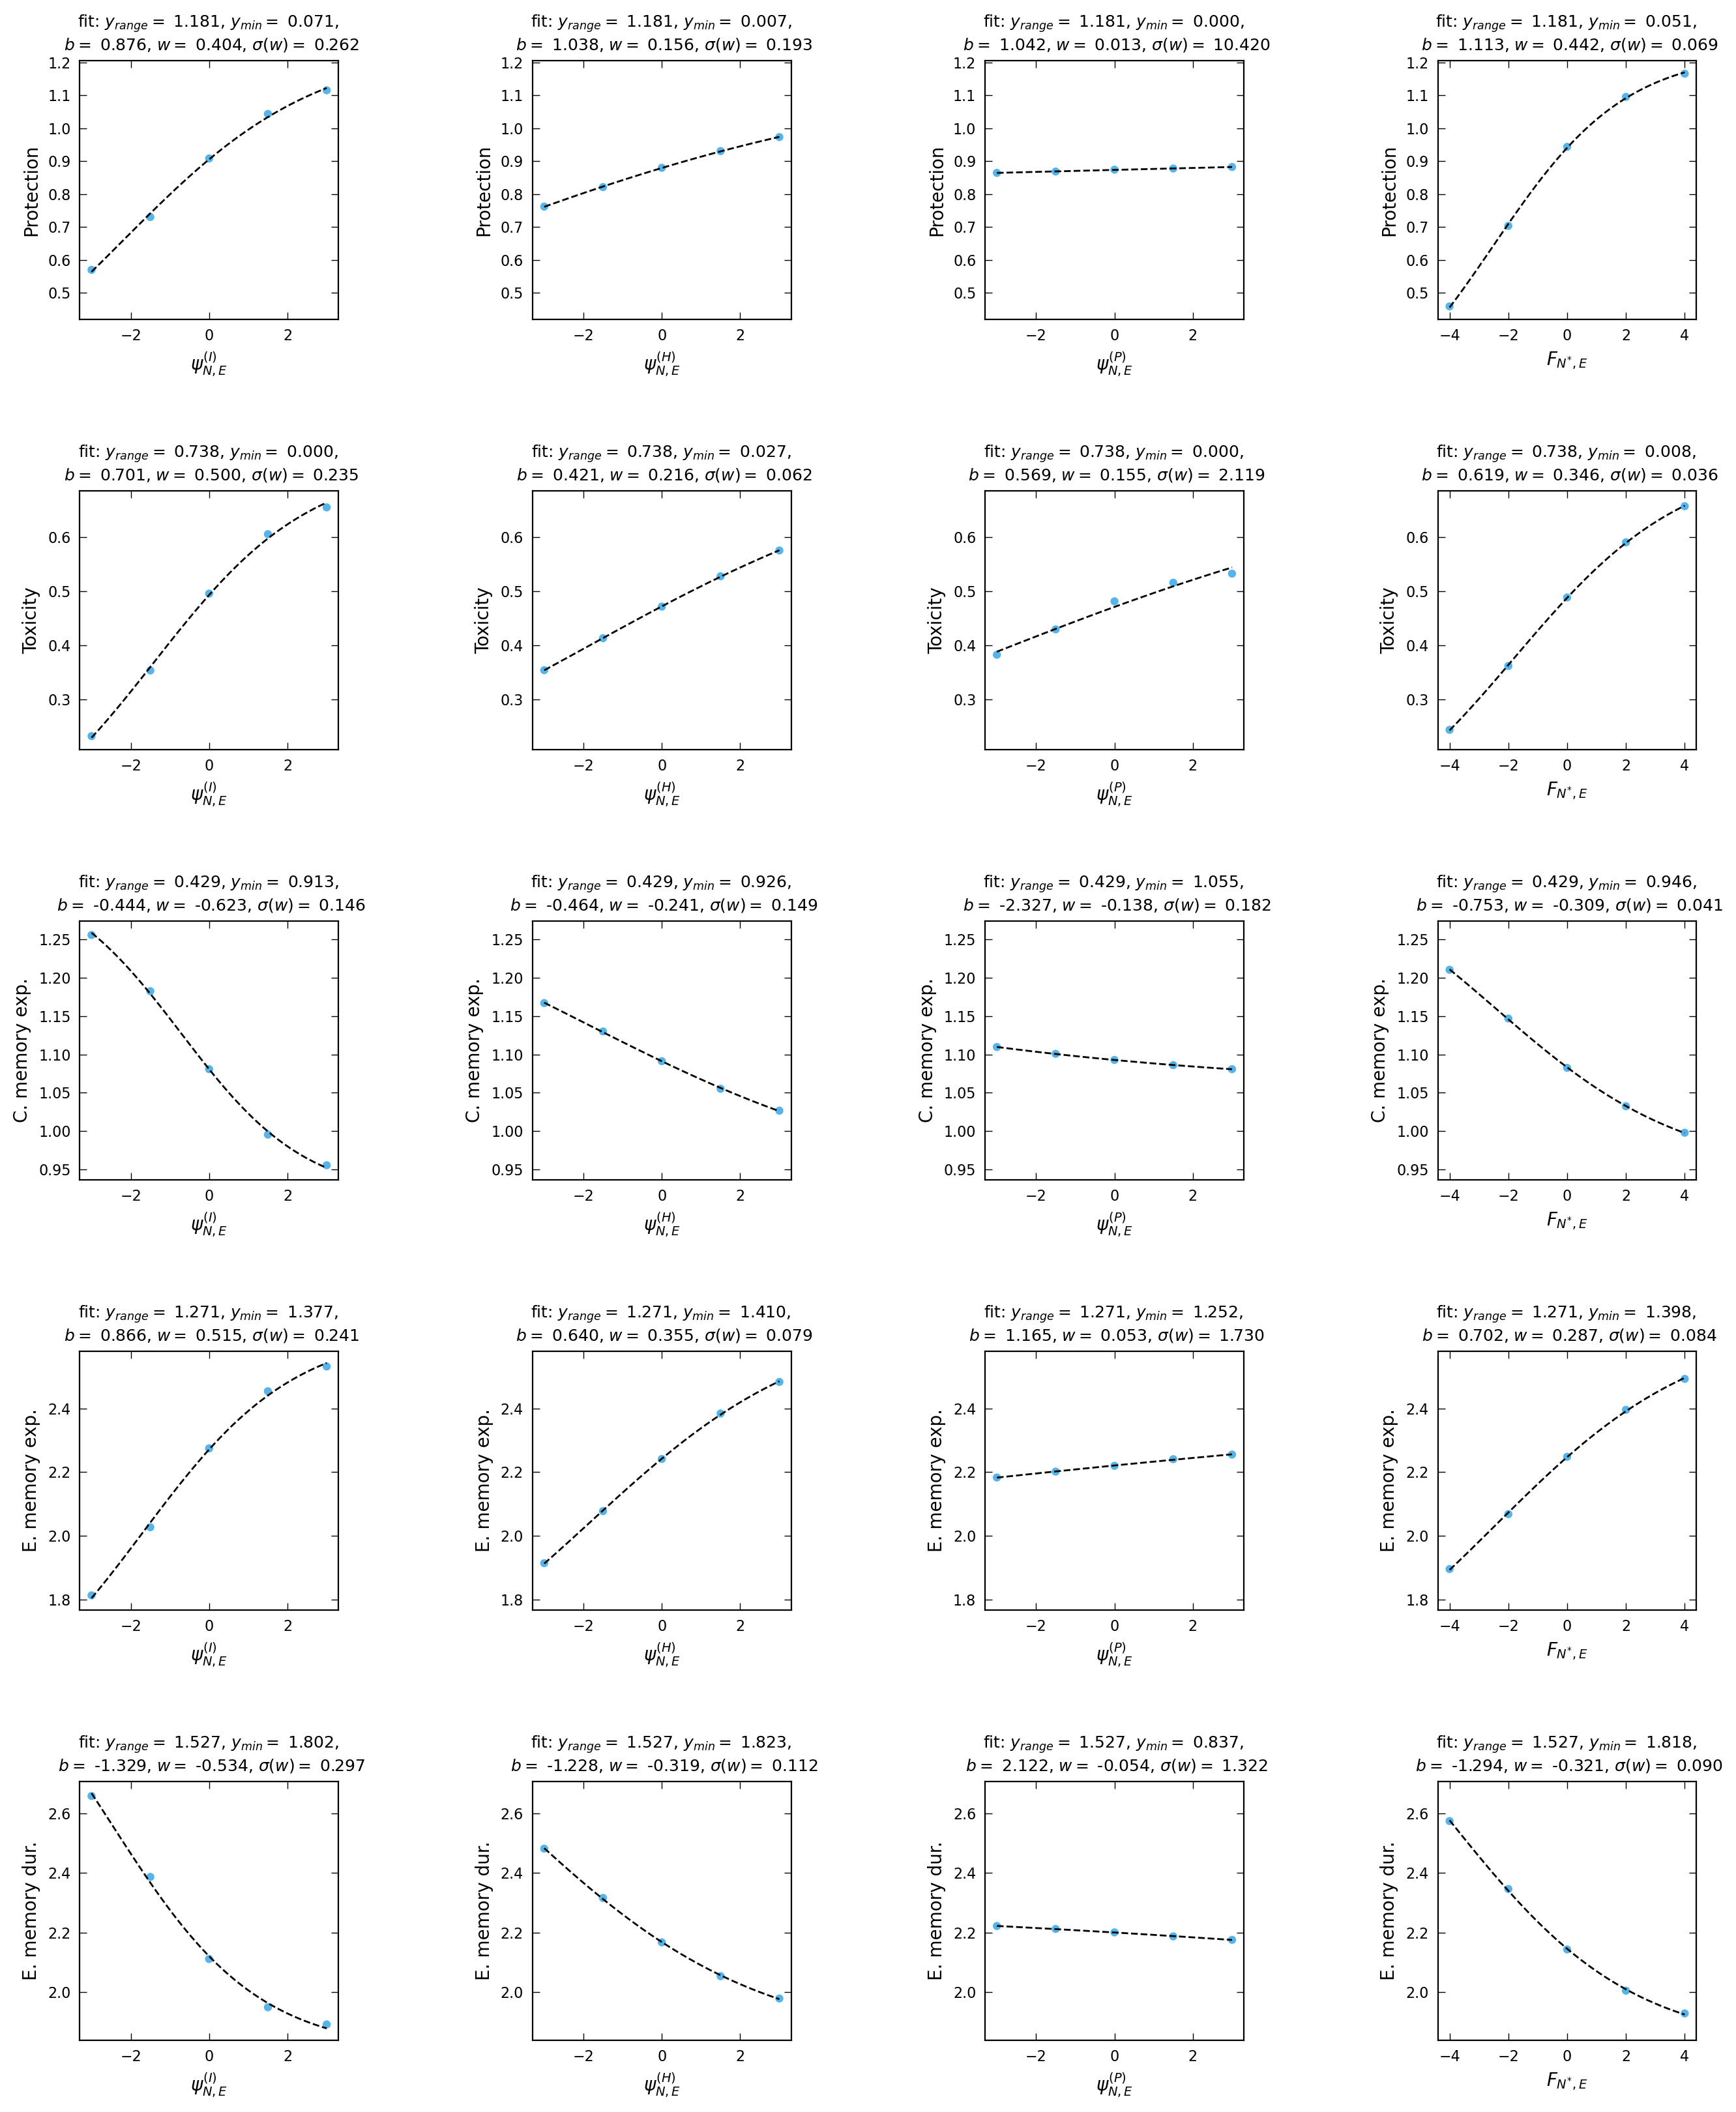

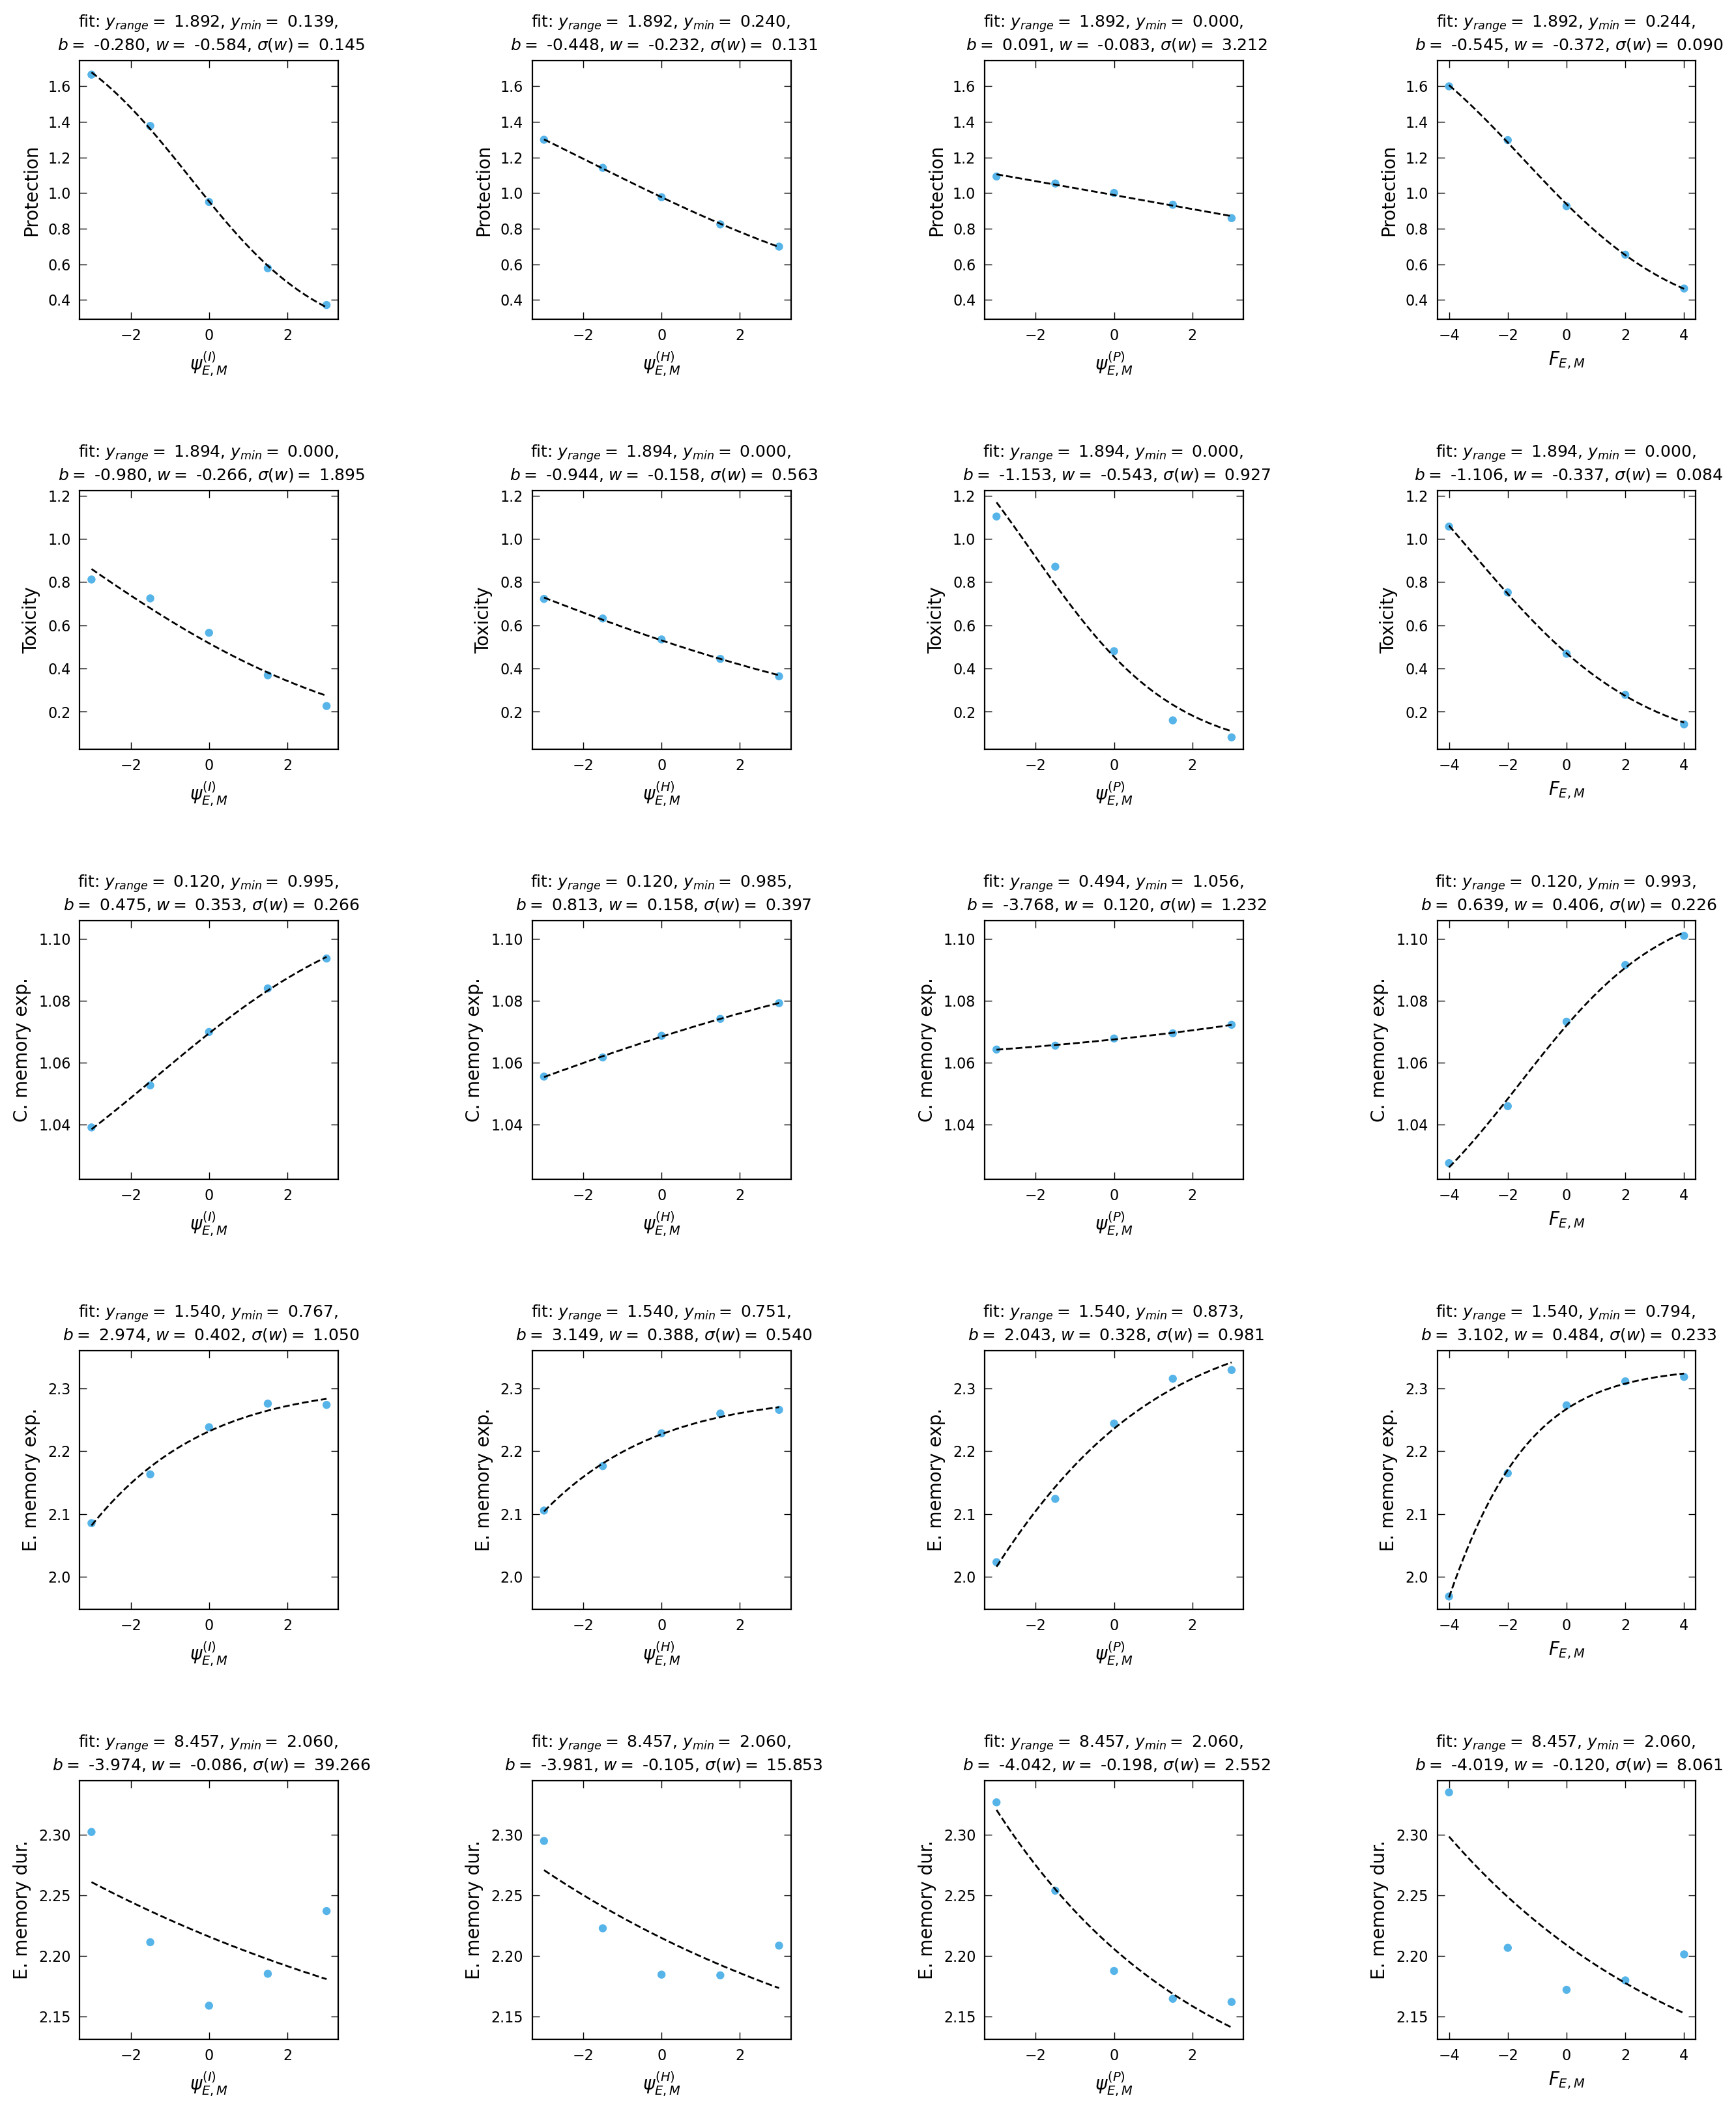

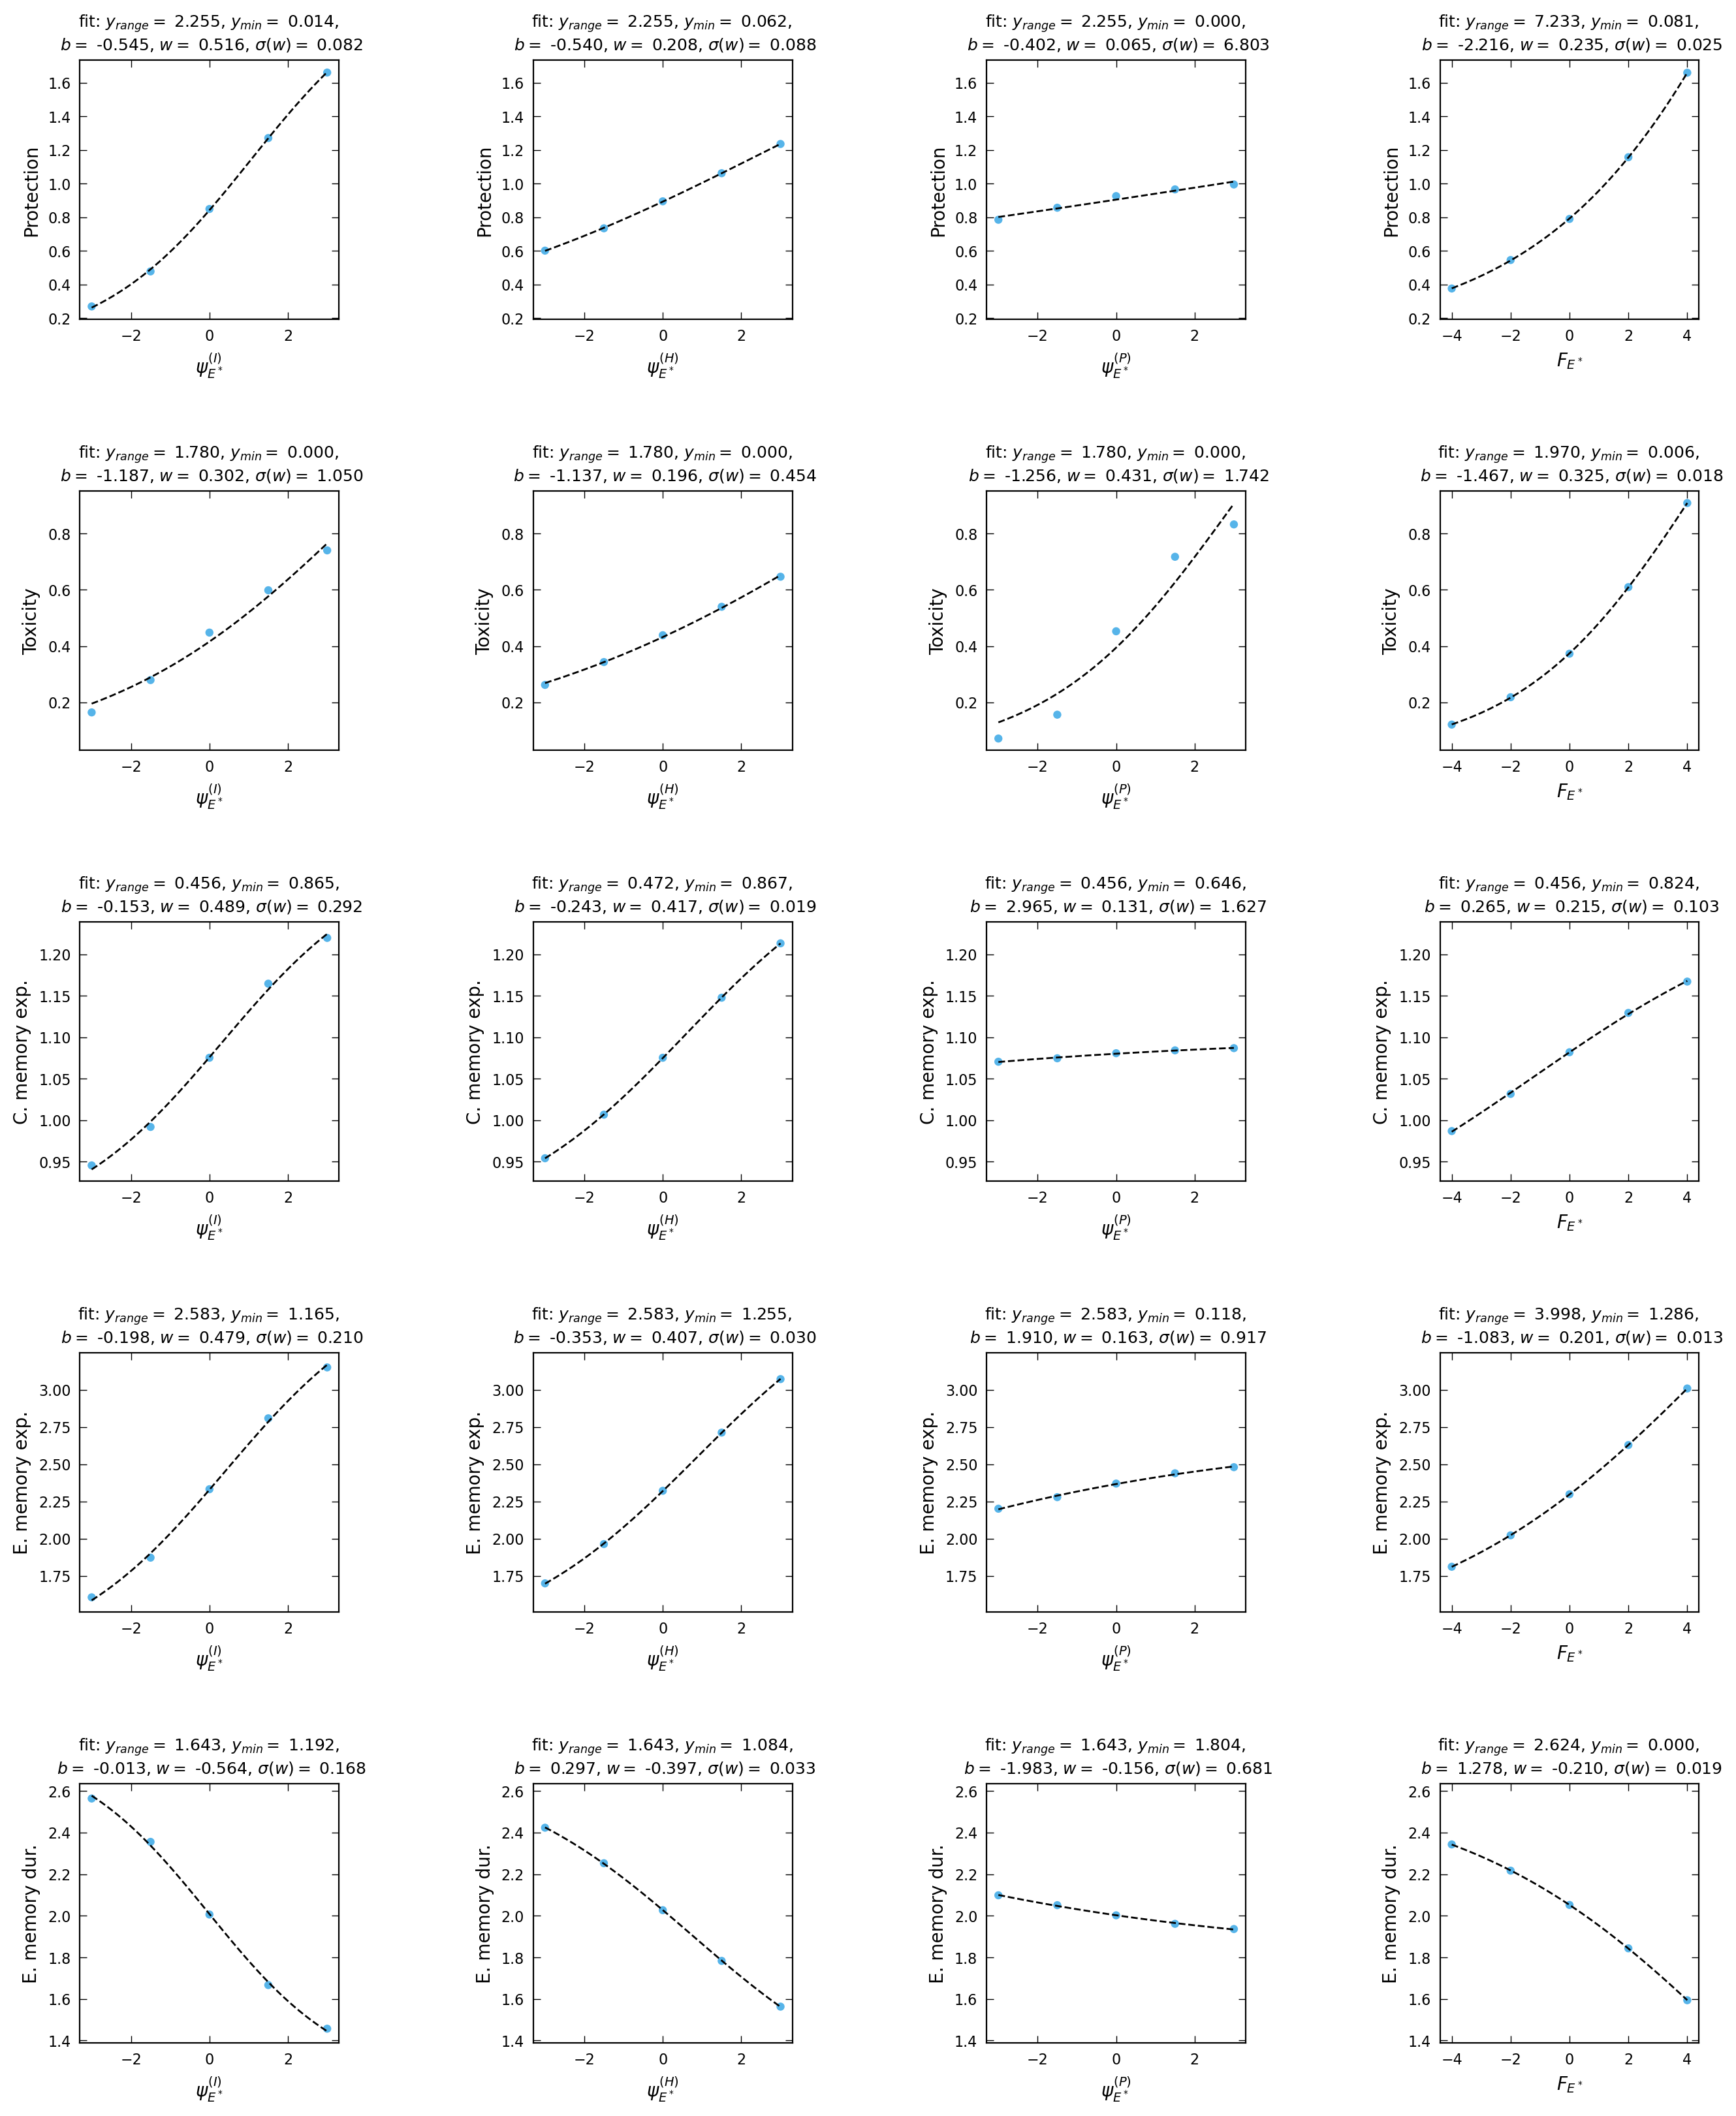

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 40
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min), 0.0 if y_min > 0.0 else y_min] + len(variables)*[-3.0*F0_max] + num_modules*[-3.0*F0_max], 
                                     [1.05*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[3.0*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [30]:
# View result
perf = 4 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
4,5.047079,0.165591,0.374235,0.855262,0.001271,3.401069,-0.016524,0.020515,-0.002137,-0.052271,-0.016243,-0.001152,-0.010204,-0.000937,-0.125021,-0.008914,-0.015727,-0.769067,-1.841147,2.974614,1.879813,2.111468,6.998422,0.002288,0.006562,0.007560,0.005998,0.026876,0.026714,0.031692,0.013695,0.075197,0.147100,0.011558,0.092448,0.008703,0.003794,0.003792,0.003795,0.003818,0.010254,1.536990,10.451784,0.012575,0.01,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,1.513992,5.0,0.0,0.000000,4.0,0.830660,1.834924,0.000000,0.180523,0.060789,0.045743,NaN
9,5.250000,0.111229,0.190858,0.246877,0.004527,1.700926,0.027070,0.059377,-0.010044,0.428048,-0.001607,-0.001804,-0.005693,0.014917,-0.072863,-0.005847,-0.007422,-1.248250,-2.481266,1.915180,1.113213,4.809686,8.604107,0.002494,0.005252,0.005335,0.005126,0.010516,0.005076,0.005102,0.005070,0.006063,0.008833,0.009732,0.028618,0.074417,0.007218,0.007264,0.007271,0.014324,0.018962,0.026424,6.632416,0.056695,0.01,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,1.105578,5.0,0.0,0.000000,4.0,0.877204,1.530247,0.000000,0.094331,0.060789,0.022929,NaN
14,5.248411,0.332644,0.426787,7.230806,0.012775,7.875041,-0.005433,-0.004451,-0.000658,-0.041258,-0.029056,0.001557,-0.010361,-0.013808,-0.138271,-0.067159,-0.019787,-0.831692,-2.258017,1.522822,2.739644,2.002152,2.421185,0.002460,0.017022,0.110495,0.015547,0.108591,0.005933,0.005431,0.004258,0.031921,0.192180,0.016143,0.069308,0.091702,0.004386,0.004390,0.004381,0.004399,0.016870,0.948380,7.081498,0.013121,0.05,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,1.607124,5.0,0.0,0.701244,4.0,0.910290,1.855211,0.000000,0.173268,0.266744,0.080713,NaN
19,5.250000,0.113208,0.139485,1.592534,-0.007983,1.796174,0.022809,0.278553,0.006023,0.438370,-0.003191,-0.003469,-0.001402,0.008308,-0.081782,-0.036645,-0.011573,-1.047733,-1.818230,2.257489,1.161134,3.775964,23.517460,0.002542,0.005078,0.009573,0.005027,0.009020,0.005418,0.006046,0.005414,0.006507,0.045769,0.049729,0.020364,0.118850,0.006135,0.006185,0.006186,0.008372,0.011463,0.028640,18.789271,0.031865,0.05,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,1.251705,5.0,0.0,0.000000,4.0,0.892043,1.621160,0.000000,0.090385,0.266744,0.029836,NaN
24,5.250000,0.118028,5.628999,1.282025,-0.000076,4.036447,-0.301424,-0.045687,-0.010400,-0.142102,-0.210139,-0.054193,-0.118912,0.218033,-0.804913,-0.223174,-0.058620,-0.318948,11.998671,1.137681,5.518266,0.963844,0.042222,0.004944,0.097196,0.025537,0.010057,0.071291,0.005944,0.002877,0.002784,0.002995,0.132971,0.099236,0.108979,0.158432,0.005938,0.003452,0.003154,0.002251,0.208936,0.029235,0.976113,0.010678,0.25,10000.0,1.500000e-07,50000.0,300.000000,10000000.0,1000.0,2.194030,5.0,0.0,1.987810,4.0,1.015481,1.711004,5.383929,5.058422,1.663586,0.557280,2.813581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,5.154704,0.070839,0.084760,1.545851,-0.002028,1.266116,0.010616,0.170254,-0.002439,0.223203,-0.005582,-0.040316,-0.005595,0.012870,-0.085200,-0.958051,-0.010888,-1.172328,-0.954741,1.740613,1.316321,4.806542,2.488004,0.003574,0.005541,0.011

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

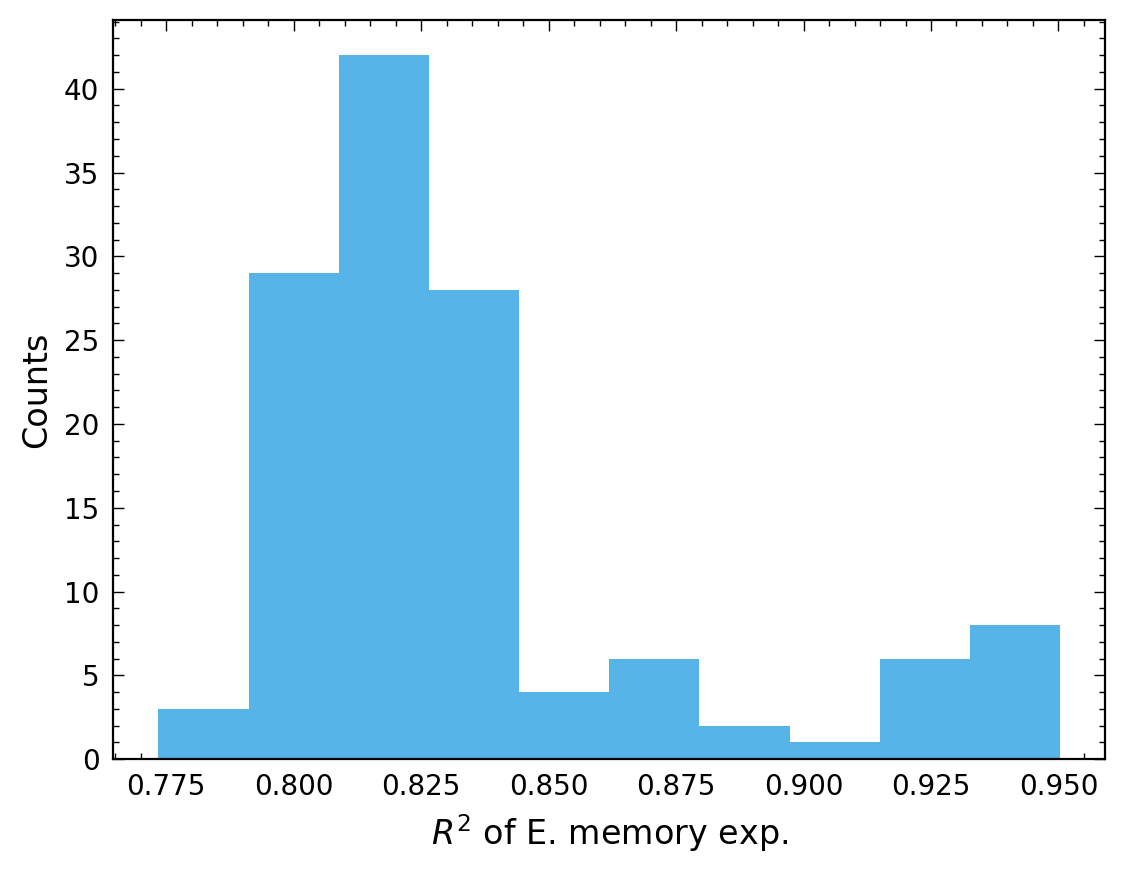

In [21]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

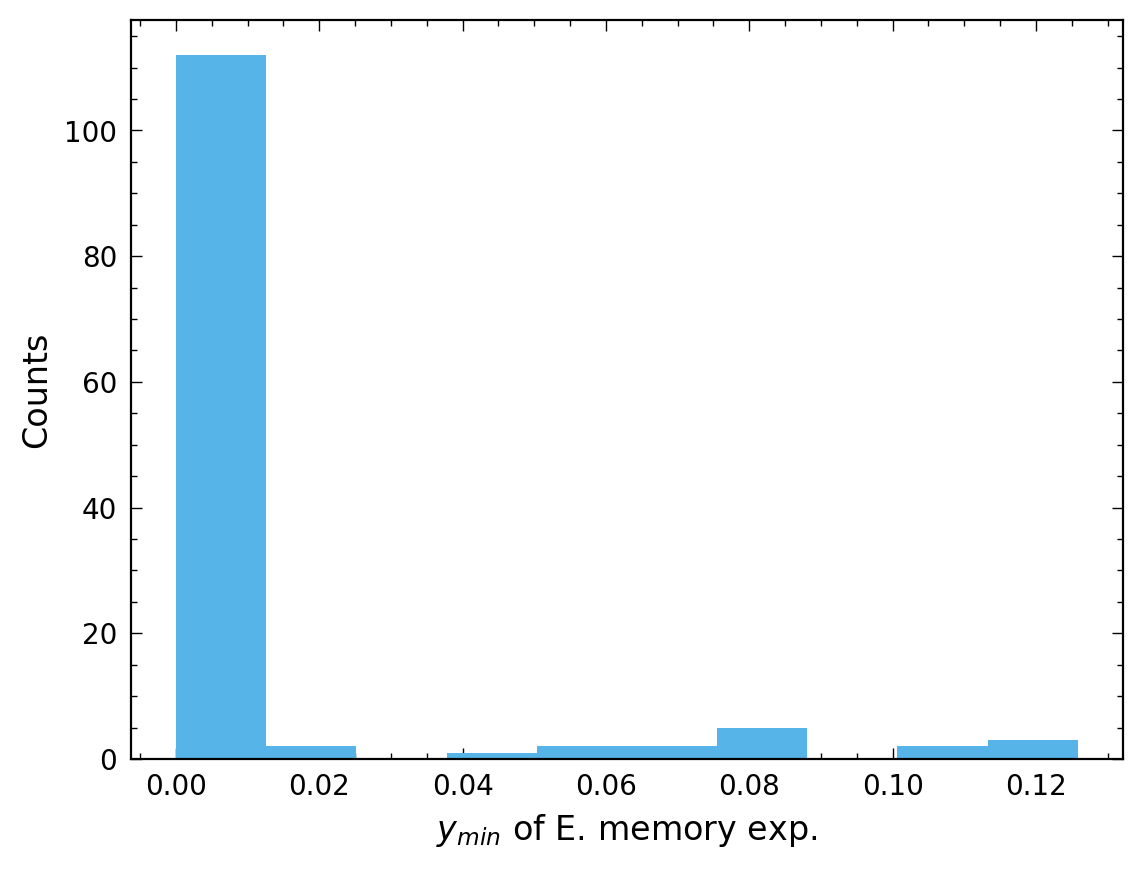

In [22]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

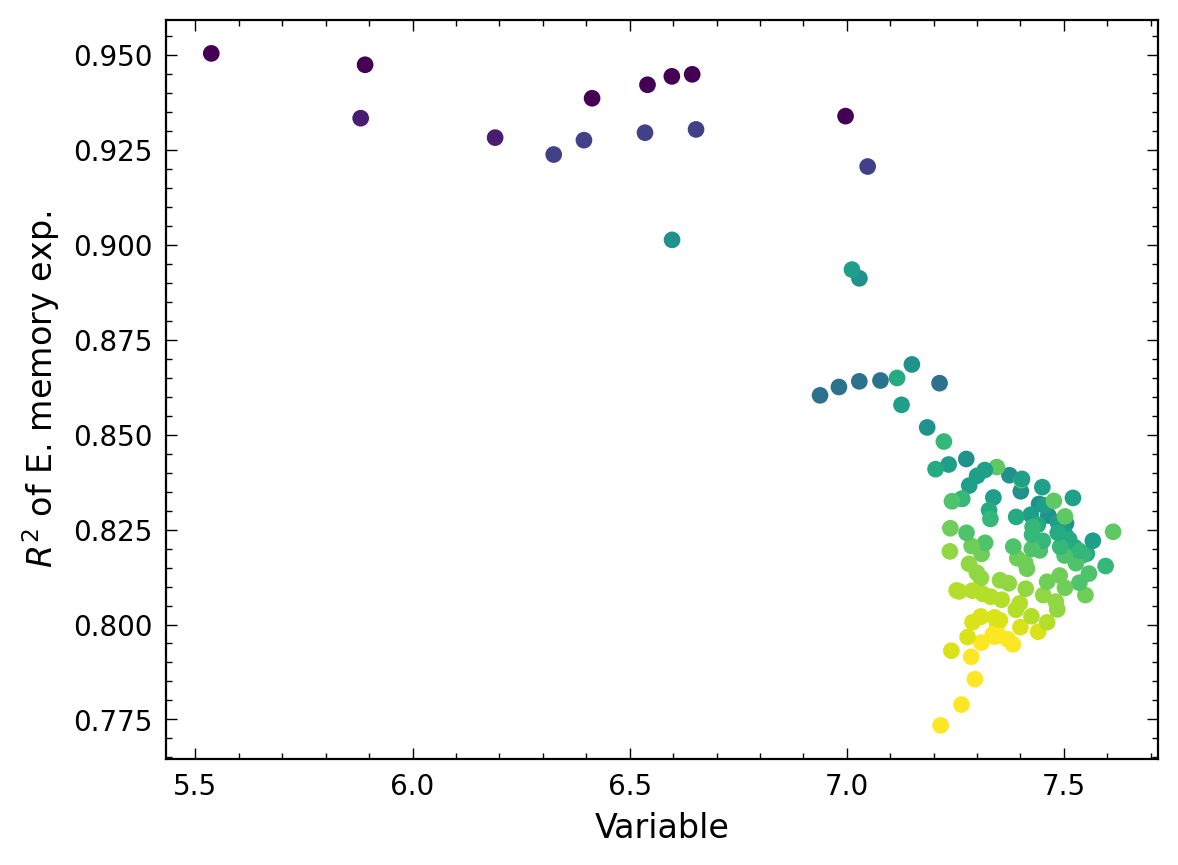

In [23]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].y_range, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

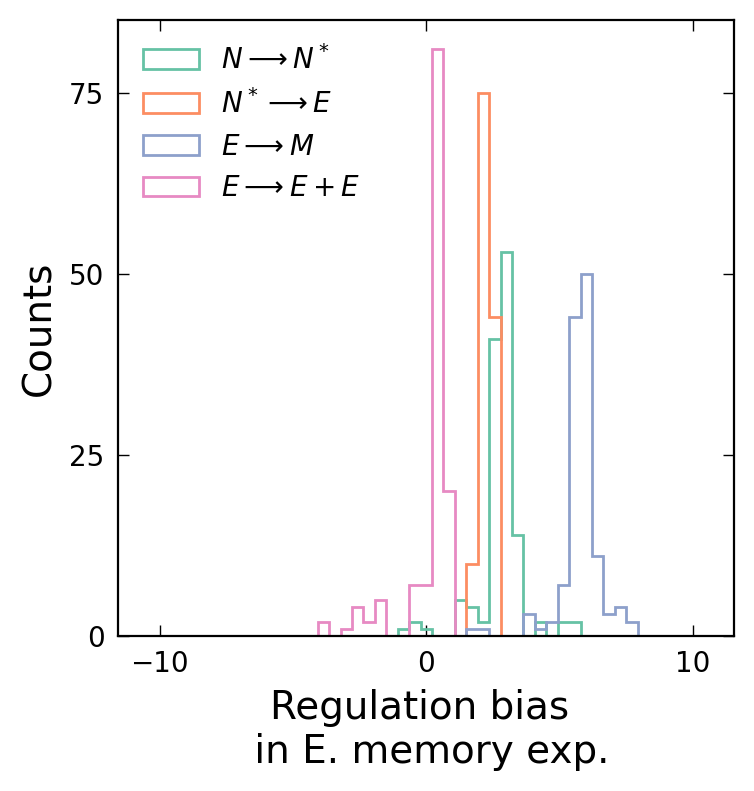

In [24]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

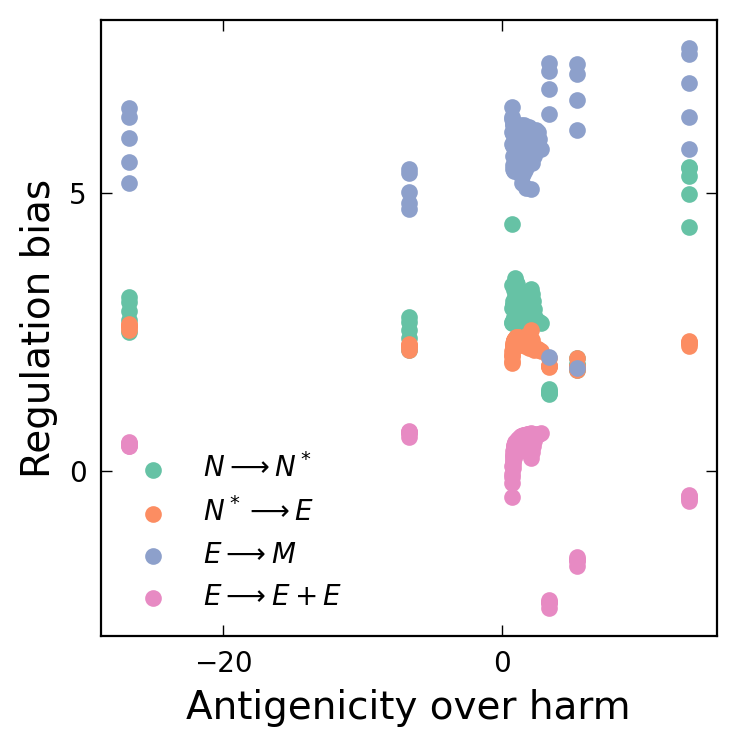

In [25]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

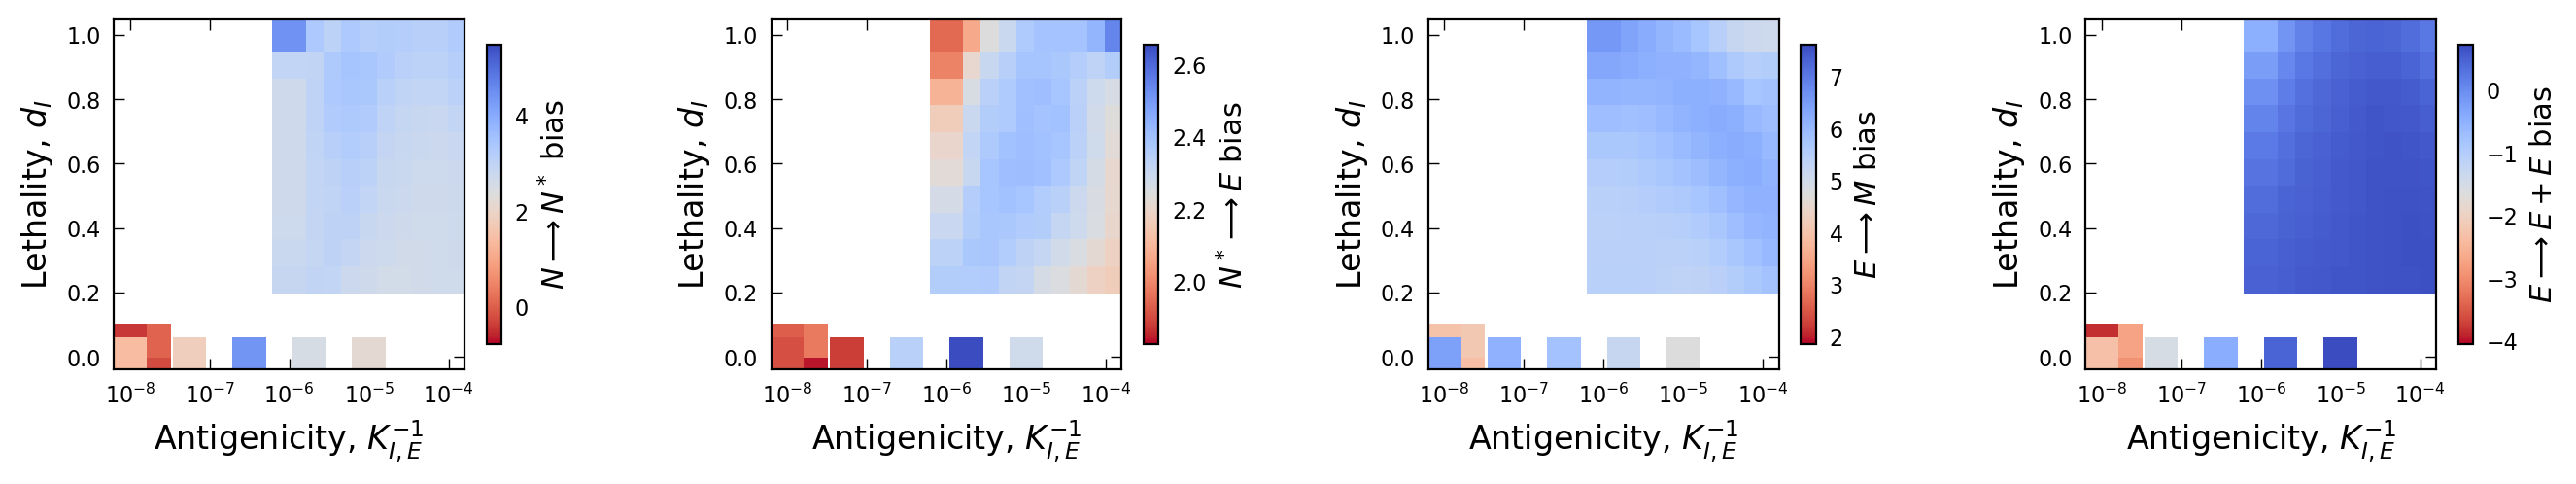

In [26]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

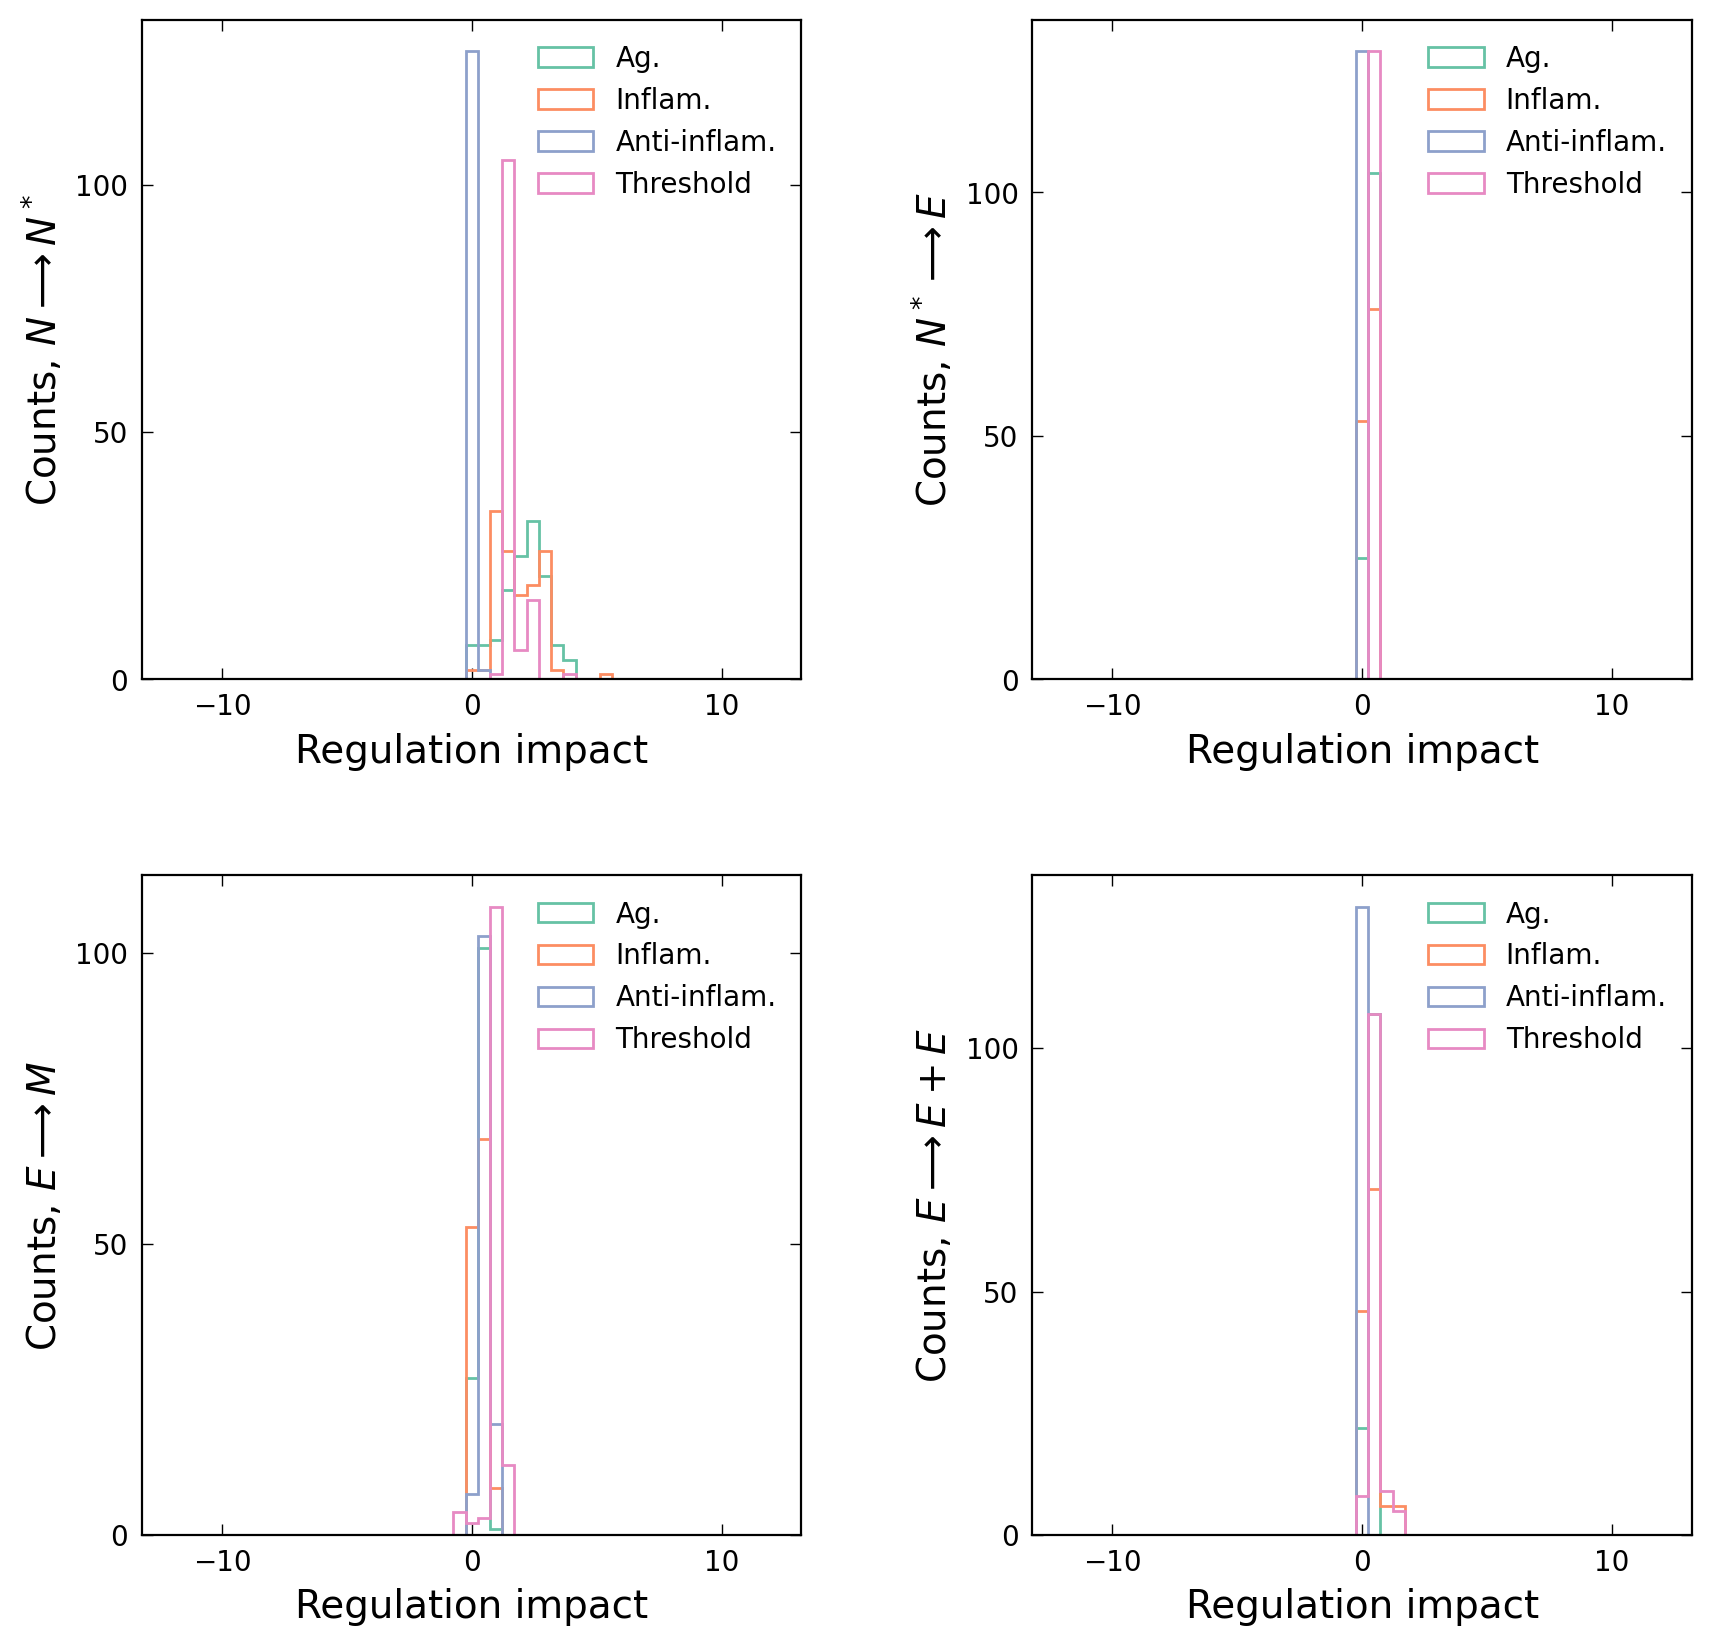

In [27]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*F0_max, 3.0*F0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [28]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
3,5.880632,4.862920e-15,0.309235,0.177327,0.060651,1.631973,0.111709,0.017915,0.060700,0.626614,-0.037092,0.000187,0.011625,-0.632659,0.280734,0.032138,0.071392,1.353933,-0.218091,1.841173,3.902867,-2.928364,0.008675,0.000727,0.002724,0.002587,0.002515,0.006789,0.002111,0.002087,0.002093,0.002106,0.004874,0.004871,0.004871,0.009086,0.001863,0.001702,0.001716,0.004697,0.002865,0.007574,0.037803,0.008008,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.562083,5.880632,0.0,0.000000,3.0,0.313986,1.215565,0.0,0.180523,0.060789,0.045743,NaN
8,5.536528,4.560616e-12,0.199615,0.211420,0.034018,1.539546,0.060362,0.005830,0.037703,0.673569,-0.022068,0.002126,0.006784,-0.648120,0.192177,0.029022,0.036375,1.525000,-0.770039,1.867081,3.851127,-4.045246,0.012473,0.000485,0.002169,0.002175,0.002116,0.004208,0.001868,0.001862,0.001864,0.001869,0.004008,0.004006,0.004007,0.007415,0.001691,0.001512,0.001517,0.007505,0.002617,0.006459,0.030736,0.012748,0.01,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.389346,5.536528,0.0,0.000000,3.0,0.222732,0.999458,0.0,0.094331,0.060789,0.022929,NaN
13,6.190212,7.390866e-21,0.277195,0.716880,0.064131,1.495116,0.099174,0.119340,0.060262,0.630057,-0.034073,-0.014332,0.007485,-0.658006,0.242230,0.149969,0.074854,1.282152,0.045192,1.975536,4.095792,-2.733012,0.009330,0.000845,0.002806,0.003747,0.002619,0.005423,0.002249,0.002258,0.002236,0.002295,0.005407,0.005405,0.005404,0.010659,0.001838,0.001774,0.001728,0.004291,0.003071,0.008412,0.044229,0.007134,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.644187,6.190212,0.0,0.003992,3.0,0.353851,1.320229,0.0,0.173268,0.266744,0.080713,NaN
18,5.890758,3.276263e-16,0.147393,0.638316,0.042119,1.478238,0.056581,0.066135,0.041618,0.658175,-0.018774,-0.004045,0.004582,-0.654864,0.170972,0.149117,0.043969,1.498326,-0.422390,1.928708,3.972726,-3.850639,0.011712,0.000570,0.002241,0.002956,0.002197,0.004355,0.001931,0.001933,0.001928,0.001956,0.004382,0.004381,0.004381,0.008377,0.001633,0.001628,0.001535,0.006870,0.002572,0.006943,0.034729,0.011794,0.05,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.461378,5.890758,0.0,0.000000,3.0,0.256575,1.118154,0.0,0.090385,0.266744,0.029836,NaN


In [29]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
523,7.613212,8.227183e-29,4.160648,1.337525,0.032681,1.385517,0.603992,0.151481,0.010596,0.309160,0.805002,0.167104,0.545159,0.752839,0.569163,0.154085,0.020807,0.279812,2.778209,2.182088,5.433083,0.619249,0.020731,0.004577,0.024258,0.009163,0.004985,0.007798,0.004702,0.003077,0.002936,0.002952,0.008894,0.006268,0.007760,0.011647,0.003083,0.001854,0.001714,0.001357,0.015471,0.015699,0.053142,0.007363,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,2.622455,7.250678,0.0,2.776332,3.0,0.930097,2.219605,2.651569,3.336130,1.135641,0.282152,-6.698971
528,7.502458,1.021687e-19,4.039999,1.292447,0.054278,1.354059,0.605116,0.150257,0.018252,0.312505,0.698392,0.152237,0.662108,0.749434,0.561700,0.150965,0.039282,0.284376,2.674626,2.245652,5.362750,0.679604,0.019803,0.004527,0.022577,0.008586,0.004819,0.007265,0.004700,0.003094,0.002958,0.003007,0.008264,0.006099,0.008113,0.011240,0.003051,0.001851,0.001727,0.001388,0.014355,0.015942,0.051081,0.007450,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,2.636711,7.145198,0.0,2.819042,3.0,0.919022,2.218795,2.651569,3.264340,1.083388,0.434895,-6.698971
533,7.476858,6.071583e-18,3.895358,1.241555,0.091553,1.314936,0.591602,0.146380,0.029740,0.307762,0.660291,0.147430,0.739579,0.668230,0.535847,0.142002,0.069536,0.281725,2.545592,2.249532,5.014116,0.701251,0.019793,0.004441,0.020691,0.007964,0.004643,0.006654,0.004624,0.003052,0.002924,0.002986,0.007667,0.005667,0.008006,0.009259,0.002948,0.001804,0.001713,0.001392,0.013077,0.015968,0.043454,0.007570,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,2.627646,7.120817,0.0,2.821061,3.0,0.900583,2.200665,2.651569,3.205409,1.055921,0.677620,-6.698971
538,7.402236,8.897934e-18,3.741515,1.183788,0.142186,1.275790,0.574369,0.140787,0.047055,0.306006,0.624842,0.136676,0.803908,0.636843,0.491785,0.126934,0.118502,0.278022,2.396031,2.265744,4.819361,0.728154,0.019670,0.004295,0.018727,0.007299,0.004453,0.006024,0.004523,0.003009,0.002899,0.002985,0.007028,0.005274,0.007767,0.008149,0.002785,0.001738,0.001726,0.001404,0.011729,0.016020,0.038697,0.007779,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,2.603027,7.049749,0.0,2.822784,3.0,0.872810,2.168546,2.651569,3.160198,1.016672,1.033744,-6.698971
543,7.345369,4.421968e-19,3.522106,1.101482,0.214153,1.222600,0.539627,0.130956,0.069225,0.297175,0.601039,0.131408,0.890652,0.609901,0.394877,0.094699,0.187298,0.266861,2.178616,2.281268,4.714872,0.711155,0.020804,0.004134,0.016443,0.006549,0.004278,0.005298,0.004472,0.003006,0.002924,0.003047,0.006612,0.005002,0.007820,0.007314,0.002466,0.001618,0.001804,0.001428,0.010125,0.016607,0.035588,0.008317,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,2.550541,6.995589,0.0,2.817008,3.0,0.842418,2.115588,2.651569,3.094451,0.985733,1.409251,-6.698971
548,7.520810,1.154448e-16,2.296836,1.422928,0.033309,1.508161,0.452125,0.276496,0.017717,0.463483,0.618654,0.350259,0.488543,1.094502,0.411710,0.265352,0.024441,0.323268,3.139589,2.547068,6.523952,0.444598,0.018913,0.004738,0.014288,0.009277,0.004130,0.009028,0.003988,0.003534,0.003208,0.003716,0.007846,0.007023,0.007470,0.018400,0.002313,0.001915,0.001547,0.001382,0.017817,0.016373,0.077321,0.006650,0.01,5.623413e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,2.561044,7.162677,0.0,2.